In [5]:
import numpy as np
import scipy
import time
import random

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
class Densitycluster():
    def __init__(self, data):
        self.data = data
        self.idx_list = [_ for _ in range(len(self.data))]
        
    def cutoff(self, xval):
        yval = self.grad * max(self.delta)* xval /max(self.rho) + self.delta_cutoff
        return(yval)        
        
    def dens(self, dist, cutoff_dist):
        return(np.e**-(dist/cutoff_dist))
    
    def build_dist_matrix(self, method = 'euclidean'):
        t1 = time.time()
        self.distances = scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(self.data))
        t2 = time.time()
        print("distance matrix built in {0} seconds".format(t2-t1))
        
    def assign_rho_delta(self, cutoff_dist, delta_cut=0.1, rho_cut=0.1, grad = -0.1, plot=True, kernel='gaussian'):
        t1 = time.time()
        self.grad = grad
        self.rho_cut = rho_cut
        self.delta_cut = delta_cut
        self.cut_dist = cutoff_dist
        if kernel == 'cutoff':
            self.rho = [sum([i < cutoff_dist for i in j]) for j in self.distances]
        elif kernel == 'gaussian':
            self.rho = []
            for i in range(len(self.data)):
                self.rho.append(sum([self.dens(d, cutoff_dist) for d in self.distances[i]]))

        print("mean rho value of {0} is {1}% of data".format(np.mean(self.rho), np.mean(self.rho)/len(self.data)*100))       
        self.delta = []
        for i in range(len(self.data)):
            try:
                self.delta.append(min([d for d, r in zip(self.distances[i], self.rho) if r > self.rho[i]]))
            except(ValueError):
                # this is a crappy way of doing this
                self.delta.append(max(self.distances[i]))
        self.delta_cutoff = max(self.delta)*self.delta_cut
        self.rho_cutoff = max(self.rho)*self.rho_cut
        t2 = time.time()
        print("delta and rho assigned in {0} seconds".format(t2-t1))
        if plot:
            
            fig1, ax1 = plt.subplots(figsize = (10, 10))
            ax1.scatter(self.rho, self.delta, s=100, alpha=0.3, edgecolors='none')
            x_points = np.linspace(0, max(self.rho), 200)           
            y_points = [self.cutoff(x) for x in x_points]
            ax1.plot(x_points, y_points, c='green')
            ax1.plot([self.rho_cutoff, self.rho_cutoff],[0, max(self.delta)], c='green')

            ax1.grid(True)
            ax1.set_xlabel('rho') 
            ax1.set_ylabel('delta')
            plt.xlim(-max(self.rho)/10, max(self.rho)+1)
            plt.ylim(-max(self.delta)/10, max(self.delta)+1)
            plt.show()
 
    def run_clustering(self, plot=True):
        t2 = time.time()

        rho_delta_array = np.array([self.rho, self.delta]).T
        mask1 = np.array([i[1] > self.cutoff(i[0]) for i in rho_delta_array])
        mask2 = np.array([i > self.rho_cutoff for i in self.rho])
        mask3 = np.logical_and(mask1, mask2)
        self.cluster_centre_idx = np.array(self.idx_list)[mask3]
        mask4 = np.array([i > self.delta_cutoff for i in self.delta])
        unclustered = np.array([_ for _ in range(len(self.data))])[np.logical_and(mask2, np.logical_not(mask1))]
        print(f"there were {len(unclustered)} points to cluster")
        excluded = np.array([_ for _ in range(len(self.data))])[np.logical_and(np.logical_not(mask2), mask4)]
        print(f"there were {len(excluded)} points excluded")

        self.pairs = []
        for unc in unclustered:
            neighbours = [x for x,y in sorted(enumerate(self.distances[unc]), key = lambda x: x[1])]
            # list of id's of neighbours, sorted by distance
            hd_neighbours = [x for x in neighbours if self.rho[x] > self.rho[unc]]
            # subset of neighbours for which rho values are smaller than that of unclustered particle
            self.pairs.append((unc, hd_neighbours[0]))

        t3 = time.time()
        print("cluster pairs identified in {0} seconds".format(t3-t2))
        self.clusters = [[x] for x in self.cluster_centre_idx]
        count = 0
        while count < len(self.pairs):
            for i in range(len(self.pairs)):
                for j in range(len(self.clusters)):
                    if self.pairs[i][1] in self.clusters[j]:
                        self.clusters[j].append(self.pairs[i][0])
                        count += 1
                        self.pairs[i] = (None, None)
        t4 = time.time()
        print("clusters assigned in {0} seconds".format(t4-t3))
        print(f"found {len(self.clusters)} clusters")
        print(f"clusters contain {[len(x) for x in self.clusters]} entries")
        if plot:
            colours = plt.cm.rainbow([[x] for x in np.linspace(0, 1, len(self.clusters))])
            
            fig = plt.figure(figsize = (20,20))
            ax = fig.add_subplot(111, projection='3d')
            for c, col in zip(self.clusters, colours):
                x = [_[0] for _ in [self.data[c1] for c1 in c]]
                y = [_[1] for _ in [self.data[c1] for c1 in c]]
                z = [_[2] for _ in [self.data[c1] for c1 in c]]
                ax.scatter(x, y, z, c=col, s=100, alpha=0.2)
            x1 = [_[0] for _ in [self.data[ex] for ex in excluded]]
            y1 = [_[1] for _ in [self.data[ex] for ex in excluded]]
            z1 = [_[2] for _ in [self.data[ex] for ex in excluded]]
            ax.scatter(x1, y1, z1,marker='s', c='grey', s=100, alpha=0.5)
            x2 = [_[0] for _ in [self.data[cen] for cen in self.cluster_centre_idx]]
            y2 = [_[1] for _ in [self.data[cen] for cen in self.cluster_centre_idx]]
            z2 = [_[2] for _ in [self.data[cen] for cen in self.cluster_centre_idx]]
            ax.scatter(x2, y2, z2, marker = '*', c='black', s=1000)          
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.set_zlabel('PC3')
            plt.show()


In [7]:
centres = [[1, 0, 4],
          [-2, 5, -3],
          [6, -2, 0],
          [-5, 4, -3]]

sigmas = [[0.5, 1, 0.1],
         [0.3, 2, 1],
         [0.5, 0.5, 0.5],
         [1, 0.1, 0.5]]

fake_data = []
for i in range(1000):
    index = random.randint(0, 3)
    entry = [random.gauss(centres[index][x], sigmas[index][x]) for x in range(len(centres[0]))]
    fake_data.append(entry)

In [8]:
fake_data[:10]

[[6.306112922958615, -1.8629994947980373, -0.1942308842283389],
 [6.481615042742053, -1.4155105548561164, -1.045479867568202],
 [-1.669072166822309, 2.9855897088366827, -5.115677315893771],
 [-2.2072481980444576, 1.6992119306593167, -2.6400164795539434],
 [0.45622920281839974, -1.0411846430268061, 4.002680568248442],
 [-1.973151600068735, 0.44166892913794964, -1.9744379769497145],
 [6.8535483031809195, -2.1808440894368633, -0.32842728903411794],
 [-4.414670030376188, 3.944003640760347, -3.0357335633334324],
 [0.9424269627419231, 0.028233609926232285, 3.999204904228847],
 [-1.8352636851777913, 1.763568427249353, -4.1970803425255445]]

In [9]:
fake_data

[[6.306112922958615, -1.8629994947980373, -0.1942308842283389],
 [6.481615042742053, -1.4155105548561164, -1.045479867568202],
 [-1.669072166822309, 2.9855897088366827, -5.115677315893771],
 [-2.2072481980444576, 1.6992119306593167, -2.6400164795539434],
 [0.45622920281839974, -1.0411846430268061, 4.002680568248442],
 [-1.973151600068735, 0.44166892913794964, -1.9744379769497145],
 [6.8535483031809195, -2.1808440894368633, -0.32842728903411794],
 [-4.414670030376188, 3.944003640760347, -3.0357335633334324],
 [0.9424269627419231, 0.028233609926232285, 3.999204904228847],
 [-1.8352636851777913, 1.763568427249353, -4.1970803425255445],
 [1.7678564369403356, 0.5272147800573859, 4.096240847945408],
 [-2.0847835930533907, 6.912940776450746, -3.803811457565472],
 [-1.9161596922154955, 6.518435769238732, -2.315642899924788],
 [-1.9064645415007193, 4.547919091147039, -3.2654219754327616],
 [0.5356034269216228, -0.4508029994093252, 3.853622183322107],
 [-2.055037769792304, 6.897514990757941, -2.

In [10]:
foo = Densitycluster(fake_data)

In [11]:
foo.build_dist_matrix()

distance matrix built in 0.053841590881347656 seconds


mean rho value of 26.29694438775239 is 2.629694438775239% of data
delta and rho assigned in 0.6713604927062988 seconds


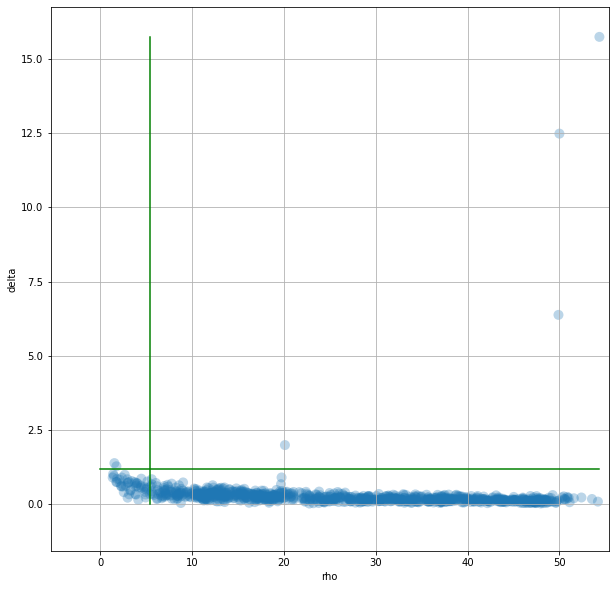

In [27]:
foo.assign_rho_delta(cutoff_dist = 0.45, delta_cut=0.075, grad=0.0)
# I had to play with the values here to get it to pick up the more diffuse cluster (low delta cluster centre)

there were 948 points to cluster
there were 2 points excluded
cluster pairs identified in 0.6159920692443848 seconds
clusters assigned in 0.9107682704925537 seconds
found 4 clusters
clusters contain [237, 329, 247, 139] entries


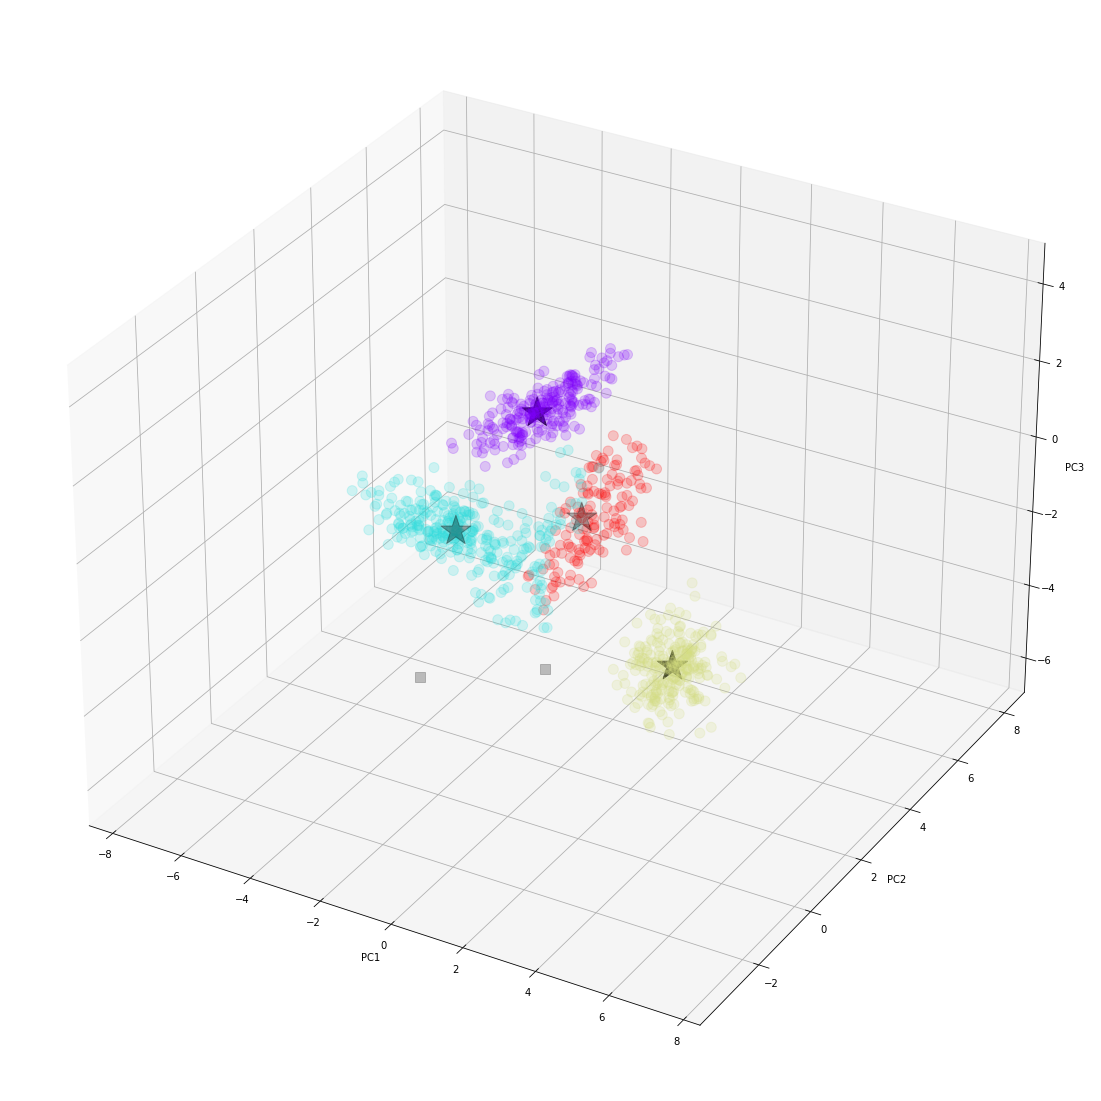

In [28]:
foo.run_clustering()